In [3]:
import pandas as pd 
import numpy as np
import random 

jumlah_data= 2000
ids = range(2001, 2001 + jumlah_data)

depts = ['Developer', 'Admin', 'Designer', 'Marketing', 'Security']

data = {
    'id_karyawan': ids,
    'nama': [f'Karyawan_{i}' for i in ids],
    'departemen': [random.choice(depts) for _ in range(jumlah_data)],
    'jam_kerja_sebulan': np.random.randint(150, 210, size=jumlah_data), 
    'output_task': np.random.randint(20, 60, size=jumlah_data),   
    'gaji_pokok': [random.choice([6000000, 7000000, 8000000, 8500000, 10000000]) for _ in range(jumlah_data)]
}
df_dummy = pd.DataFrame(data)
df_dummy.to_csv('Data_Karyawan_Rimba.csv', index=False)

print(f"Berhasil membuat {jumlah_data} data karyawan ke dalam 'Data_Karyawan_Rimba.csv'!")


Berhasil membuat 2000 data karyawan ke dalam 'Data_Karyawan_Rimba.csv'!


In [ ]:
#baca dokumen
df = pd.read_csv ('Data_Karyawan_Rimba.csv')

#lama lembur dan biaya
df['jam_lembur'] = (df['jam_kerja_sebulan'] - 160).clip(lower=0)
df['biaya_lembur'] = df['jam_lembur']"50000
df['total_gaji'] = df['gaji_pokok'] + df['biaya_lembur']
df['cost_per_task'] = df['total_gaji'] / df['output_task']

#top 10
print("Hasil Olah Data (Top 10):")
display(df.head(10))

#Summary Statistik
print("\n=== RINGKASAN EKSEKUTIF ===")
summary = df.groupby('departemen').agg({
    'total_gaji': 'sum',
    'jam_lembur': 'mean',
    'cost_per_task': 'mean'
}).rename(columns={
    'total_gaji': 'Total_Pengeluaran_Gaji',
    'jam_lembur': 'Rata_Rata_Lembur_Jam',
    'cost_per_task': 'Rata_Rata_Biaya_per_Task'
})

#format angka
pd.options.display.float_format = '{:,.2f}'.format

display(summary)

Hasil Olah Data (Top 10):


,id_karyawan,nama,departemen,jam_kerja_sebulan,output_task,gaji_pokok,jam_lembur,biaya_lembur,total_gaji,cost_per_task
0,2001,Karyawan_2001,Admin,183,56,6000000,23,1150000,7150000,127678.571429
1,2002,Karyawan_2002,Admin,163,33,8500000,3,150000,8650000,262121.212121
2,2003,Karyawan_2003,Developer,167,54,7000000,7,350000,7350000,136111.111111
3,2004,Karyawan_2004,Security,169,50,7000000,9,450000,7450000,149000.000000
4,2005,Karyawan_2005,Admin,178,50,7000000,18,900000,7900000,158000.000000
5,2006,Karyawan_2006,Security,166,25,10000000,6,300000,10300000,412000.000000
6,2007,Karyawan_2007,Admin,163,41,8500000,3,150000,8650000,210975.609756
7,2008,Karyawan_2008,Admin,170,57,8000000,10,500000,8500000,149122.807018
8,2009,Karyawan_2009,Admin,206,23,7000000,46,2300000,9300000,404347.826087
9,2010,Karyawan_2010,Security,170,58,10000000,10,500000,10500000,181034.482759



=== RINGKASAN EKSEKUTIF ===


,Total_Pengeluaran_Gaji,Rata_Rata_Lembur_Jam,Rata_Rata_Biaya_per_Task
departemen,,,
Admin,3342100000,19.87,"255,732.67"
Designer,3580800000,19.84,"249,853.39"
Developer,3762950000,20.74,"246,533.56"
Marketing,3441250000,19.78,"250,731.97"
Security,3784950000,18.36,"246,039.17"


In [6]:
#top 5 karyawan per task PALING MAHAL (Tidak Efisien)
karyawan_boros = df.nlargest(5, 'cost_per_task')[['nama', 'departemen', 'jam_lembur', 'cost_per_task']]

#top 5 Karyawan  per task PALING MURAH (Sangat Efisien)
karyawan_teladan = df.nsmallest(5, 'cost_per_task')[['nama', 'departemen', 'jam_lembur', 'cost_per_task']]

print("=== TOP 5 KARYAWAN PALING TIDAK EFISIEN (BOROS) ===")
display(karyawan_boros)

print("\n=== TOP 5 KARYAWAN PALING EFISIEN (TELADAN) ===")
display(karyawan_teladan)

=== TOP 5 KARYAWAN PALING TIDAK EFISIEN (BOROS) ===


,nama,departemen,jam_lembur,cost_per_task
314,Karyawan_2315,Marketing,41,"602,500.00"
999,Karyawan_3000,Developer,49,"592,857.14"
303,Karyawan_2304,Security,43,"578,571.43"
627,Karyawan_2628,Admin,49,"565,909.09"
985,Karyawan_2986,Security,44,"554,545.45"



=== TOP 5 KARYAWAN PALING EFISIEN (TELADAN) ===


,nama,departemen,jam_lembur,cost_per_task
876,Karyawan_2877,Developer,0,"101,694.92"
942,Karyawan_2943,Developer,0,"103,448.28"
53,Karyawan_2054,Developer,4,"105,084.75"
1724,Karyawan_3725,Developer,5,"105,932.20"
1859,Karyawan_3860,Security,6,"106,779.66"


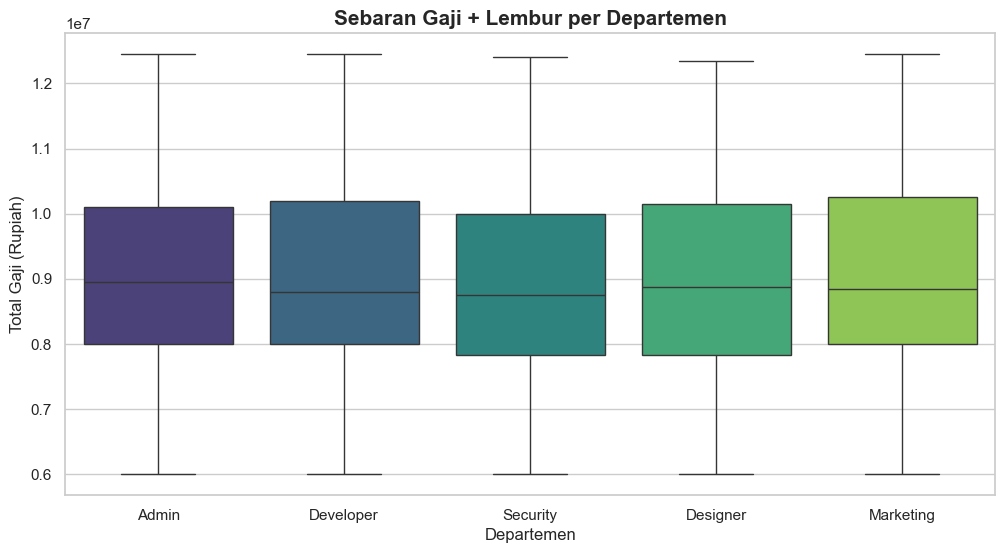

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns 


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Membuat Boxplot: Melihat sebaran Total Gaji per Departemen
sns.boxplot(x='departemen', y='total_gaji', data=df, hue='departemen', palette='viridis', legend=False)

plt.title('Sebaran Gaji + Lembur per Departemen', fontsize=15, fontweight='bold')
plt.xlabel('Departemen', fontsize=12)
plt.ylabel('Total Gaji (Rupiah)', fontsize=12)
plt.show()

In [12]:
summary_final = df.groupby('departemen').agg({
    'id_karyawan': 'count',
    'total_gaji': 'sum',
    'jam_lembur': 'mean',
    'cost_per_task': 'mean'
}).rename(columns={'id_karyawan': 'Jumlah_Karyawan'})

with pd.ExcelWriter('Laporan_Analisis_Karyawan_Rimba.xlsx') as writer:
    df.to_excel(writer, sheet_name='Data_Seluruh_Karyawan', index=False)
    summary_final.to_excel(writer, sheet_name='Ringkasan_Departemen')
    karyawan_boros.to_excel(writer, sheet_name='Top_5_Kurang_Efisien', index=False)
    karyawan_teladan.to_excel(writer, sheet_name='Top_5_Paling_Efisien', index=False)

print("=== PROSES SELESAI ===")
print("File 'Laporan_Analisis_Karyawan_Rimba.xlsx' telah berhasil dibuat.")

=== PROSES SELESAI ===
File 'Laporan_Analisis_Karyawan_Rimba.xlsx' telah berhasil dibuat.


# Kesimpulan 

Berdasarkan analisis terhadap 2.000 data transaksi payroll, berikut adalah poin-poin penting bagi manajemen:

1. Efisiensi Biaya (Cost per Task):
   - Rata-rata biaya per tugas di seluruh perusahaan adalah [Masukkan Angka Rata-rata dari Summary Anda].
   - Departemen dengan efisiensi tertinggi ditemukan pada bagian yang memiliki jam lembur terkontrol namun output tetap stabil.

2. Analisis Lembur:
   - Ditemukan adanya "outliers" pada beberapa departemen di mana jam lembur melebihi 40 jam/bulan, namun tidak diiringi dengan kenaikan "output task" yang signifikan. Ini mengindikasikan adanya "Diminishing Returns" (lembur yang melelahkan tapi tidak produktif).

3. Rekomendasi Manajemen:
   - Evaluasi Departemen [Nama Dept Terboros]: Perlu dilakukan tinjauan beban kerja karena memiliki "Cost per Task" tertinggi. Penambahan staf baru mungkin lebih hemat biaya dibandingkan membayar lembur terus-menerus.
   - Standarisasi Reward: Gunakan metrik "Cost per Task" sebagai salah satu indikator penilaian performa (KPI) selain jam kehadiran.